In [27]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mariambahi/test-image/IMG_20191215_112412.jpg
/kaggle/input/datasets/mariambahi/model-weights/tomato_maturity_best.pt
/kaggle/input/datasets/mariambahi/model-weights/tomato_maturity_last.pt


In [28]:
!pip install roboflow -q

from roboflow import Roboflow
rf = Roboflow(api_key="QNnfR8VirZzxLqHvOAuH")
project = rf.workspace("mariam-bahi").project("tomato-ripness-dyrkj")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


# Inspect the downloaded structure

In [29]:
import os, yaml

data_yaml_path = os.path.join(dataset.location, "data.yaml")
with open(data_yaml_path, "r") as f:
    data_cfg = yaml.safe_load(f)

print(data_cfg)

{'names': ['unripe', 'half_ripe', 'ripe'], 'nc': 3, 'roboflow': {'license': 'Public Domain', 'project': 'tomato-ripness-dyrkj', 'url': 'https://universe.roboflow.com/mariam-bahi/tomato-ripness-dyrkj/dataset/1', 'version': 1, 'workspace': 'mariam-bahi'}, 'test': '../test/images', 'train': '../train/images', 'val': '../valid/images'}


# Remap labels from 6 classes → 3 classes

In [30]:
import glob

# Map ORIGINAL class name -> NEW merged class name
merge_map = {
    "b_green": "unripe",
    "l_green": "unripe",
    "b_half_ripened": "half_ripe",
    "l_half_ripened": "half_ripe",
    "b_fully_ripened": "ripe",
    "l_fully_ripened": "ripe",
}

new_classes = ["unripe", "half_ripe", "ripe"]  # fixed final order -> ids 0,1,2

old_names = data_cfg["names"]  # original ordered class list
old_id_to_new_id = {
    old_id: new_classes.index(merge_map[old_name])
    for old_id, old_name in enumerate(old_names)
}
print("old_id -> new_id map:", old_id_to_new_id)

label_files = glob.glob(os.path.join(dataset.location, "**", "labels", "*.txt"), recursive=True)
print(f"Found {len(label_files)} label files")

for lf in label_files:
    new_lines = []
    with open(lf, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            old_id = int(parts[0])
            new_id = old_id_to_new_id[old_id]
            parts[0] = str(new_id)
            new_lines.append(" ".join(parts))
    with open(lf, "w") as f:
        f.write("\n".join(new_lines) + ("\n" if new_lines else ""))

print("Relabeling done.")

KeyError: 'unripe'

# Rewrite data.yaml with the new class list

In [31]:
data_cfg["nc"] = len(new_classes)
data_cfg["names"] = new_classes

with open(data_yaml_path, "w") as f:
    yaml.safe_dump(data_cfg, f)

print(data_cfg)

{'names': ['unripe', 'half_ripe', 'ripe'], 'nc': 3, 'roboflow': {'license': 'Public Domain', 'project': 'tomato-ripness-dyrkj', 'url': 'https://universe.roboflow.com/mariam-bahi/tomato-ripness-dyrkj/dataset/1', 'version': 1, 'workspace': 'mariam-bahi'}, 'test': '../test/images', 'train': '../train/images', 'val': '../valid/images'}


# Train (transfer learning on YOLOv8)

In [ ]:
!pip install ultralytics -q

from ultralytics import YOLO

In [32]:
# model = YOLO("yolov8n.pt")  # pretrained COCO weights, small/fast; use yolov8s.pt if you want more accuracy

# results = model.train(
#     data=data_yaml_path,
#     epochs=60,
#     imgsz=640,
#     batch=16,
#     patience=15,          # early stopping if val doesn't improve
#     project="tomato_maturity",
#     name="yolov8n_run1",
#     exist_ok=True
# )

In [33]:
# model = YOLO("yolov8s.pt")   # upgrade from nano -> small (more capacity to catch missed/small fruits)

# results = model.train(
#     data=data_yaml_path,
#     epochs=100,           # more epochs since bigger model + higher res need longer to converge
#     imgsz=960,             # higher resolution catches small/occluded/clustered tomatoes
#     batch=8,               # lower batch since imgsz went up (T4 has 14.9GB VRAM)
#     patience=20,
#     lr0=0.001,
#     project="tomato_maturity",
#     name="yolov8s_run1",
#     exist_ok=True
# )

In [34]:
model = YOLO("yolov8n.pt")

results = model.train(
    data=data_yaml_path,
    epochs=100,
    imgsz=960,        # keep the higher resolution — that's cheap and orthogonal to model size
    batch=16,          # can go back up since nano uses less VRAM
    patience=20,
    lr0=0.001,
    project="tomato_maturity",
    name="yolov8n_run2",
    exist_ok=True
)

Ultralytics 8.4.154 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/tomato-ripness-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_run2, nbs=64, nms=None, o

`get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.


      2/100         6G      1.521      1.961       1.41        188        960: 100% ━━━━━━━━━━━━ 121/121 2.9it/s 42.3s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.7it/s 2.2s0.5s
                   all        161       1907      0.593      0.428      0.406      0.258

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/100         6G      1.524      1.898      1.439        177        960: 100% ━━━━━━━━━━━━ 121/121 2.8it/s 42.8s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.3it/s 2.6s0.5s
                   all        161       1907      0.553      0.395      0.371      0.201

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/100         6G      1.452      1.739        1.4        168        960: 100% ━━━━━━━━━━━━ 121/121 2.9it/s 41.8s0.2s
                 Class     Images  In

# Model Evaluation

In [35]:
# Run validation on the best checkpoint
metrics = model.val(data=data_yaml_path, split="val")  # use split="test" if you have a separate test set

print("=== Overall Metrics ===")
print(f"mAP50:      {metrics.box.map50:.4f}")
print(f"mAP50-95:   {metrics.box.map:.4f}")
print(f"Precision:  {metrics.box.mp:.4f}")
print(f"Recall:     {metrics.box.mr:.4f}")

print("\n=== Per-Class Metrics ===")
class_names = model.names  # {0: 'unripe', 1: 'half_ripe', 2: 'ripe'}
for i, cls_name in class_names.items():
    p, r, ap50, ap = metrics.box.class_result(i)
    print(f"{cls_name:12s} | Precision: {p:.4f} | Recall: {r:.4f} | mAP50: {ap50:.4f} | mAP50-95: {ap:.4f}")

# Confusion matrix + PR curves are auto-saved as images
print("\nConfusion matrix & curves saved at:", metrics.save_dir)

Ultralytics 8.4.154 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3919.1±767.9 MB/s, size: 286.3 KB)
val: Scanning /kaggle/working/tomato-ripness-1/valid/labels.cache... 161 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 161/161 61.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 2.6it/s 4.2s0.2s
                   all        161       1907      0.761      0.499      0.531       0.43
                unripe        140       1247      0.841      0.466      0.514      0.402
             half_ripe        117        333      0.682      0.489      0.505      0.417
                  ripe         98        327       0.76      0.541      0.574      0.471
Speed: 4.2ms preprocess, 6.9ms inference, 0.0ms loss, 4.9ms postprocess per image
Results saved to /kaggle/working/r

In [36]:
# yolo v8 nano fine tuning
#                  Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 3.7it/s 2.9s0.1s
#                    all        161       1907      0.801       0.48      0.525      0.413
#                 unripe        140       1247      0.858      0.445      0.498      0.376
#              half_ripe        117        333      0.783      0.435      0.504      0.393
#                   ripe         98        327      0.761       0.56      0.573      0.469
# Speed: 2.1ms preprocess, 4.3ms inference, 0.0ms loss, 4.5ms postprocess per image
# Results saved to /kaggle/working/runs/detect/val
# === Overall Metrics ===
# mAP50:      0.5251
# mAP50-95:   0.4128
# Precision:  0.8005
# Recall:     0.4799

# === Per-Class Metrics ===
# unripe       | Precision: 0.8577 | Recall: 0.4446 | mAP50: 0.4984 | mAP50-95: 0.3764
# half_ripe    | Precision: 0.7825 | Recall: 0.4354 | mAP50: 0.5044 | mAP50-95: 0.3929
# ripe         | Precision: 0.7614 | Recall: 0.5596 | mAP50: 0.5726 | mAP50-95: 0.4690


In [37]:
# yolo v8 small fine tuning results 
#                  Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 2.1it/s 5.3s0.4s
#                    all        161       1907      0.802      0.489      0.534      0.439
#                 unripe        140       1247      0.869      0.469      0.517       0.41
#              half_ripe        117        333      0.722      0.467      0.511      0.433
#                   ripe         98        327      0.817      0.531      0.573      0.472
# Speed: 3.3ms preprocess, 17.9ms inference, 0.0ms loss, 4.1ms postprocess per image
# Results saved to /kaggle/working/runs/detect/val-4
# === Overall Metrics ===
# mAP50:      0.5339
# mAP50-95:   0.4387
# Precision:  0.8023
# Recall:     0.4892

# === Per-Class Metrics ===
# unripe       | Precision: 0.8686 | Recall: 0.4691 | mAP50: 0.5174 | mAP50-95: 0.4103
# half_ripe    | Precision: 0.7217 | Recall: 0.4672 | mAP50: 0.5110 | mAP50-95: 0.4332
# ripe         | Precision: 0.8166 | Recall: 0.5312 | mAP50: 0.5732 | mAP50-95: 0.4725

# Locate, save, and download the final weights (so nothing is lost)

In [38]:
import shutil
from pathlib import Path

run_dir = Path(model.trainer.save_dir)
best_pt = run_dir / "weights" / "best.pt"
last_pt = run_dir / "weights" / "last.pt"

final_dir = Path("/kaggle/working/final_weights")
final_dir.mkdir(exist_ok=True, parents=True)
shutil.copy(best_pt, final_dir / "tomato_maturity_best.pt")
shutil.copy(last_pt, final_dir / "tomato_maturity_last.pt")

print("Saved to:", list(final_dir.iterdir()))
print("These files will appear under the 'Output' tab of your Kaggle notebook after it finishes running — download from there.")

Saved to: [PosixPath('/kaggle/working/final_weights/tomato_maturity_best.pt'), PosixPath('/kaggle/working/final_weights/tomato_maturity_last.pt')]
These files will appear under the 'Output' tab of your Kaggle notebook after it finishes running — download from there.


# Save Model for deployment

In [39]:
!pip install ultralytics -q

In [40]:
from ultralytics import YOLO
from pathlib import Path

# Point directly to where this run saved its weights
best_pt = Path("/kaggle/working/final_weights/tomato_maturity_best.pt")
last_pt = Path("/kaggle/working/final_weights/tomato_maturity_last.pt")

# Sanity check the files actually exist before proceeding
print("best.pt exists:", best_pt.exists())
print("last.pt exists:", last_pt.exists())

# Reload the model from the checkpoint (needed to get model.names for the config)
model = YOLO(str(best_pt))
print("Classes:", model.names)

best.pt exists: True
last.pt exists: True
Classes: {0: 'unripe', 1: 'half_ripe', 2: 'ripe'}


In [41]:
import shutil
import json

deploy_dir = Path("/kaggle/working/tomato_maturity_deploy")
deploy_dir.mkdir(exist_ok=True, parents=True)

shutil.copy(best_pt, deploy_dir / "tomato_maturity_best.pt")
shutil.copy(last_pt, deploy_dir / "tomato_maturity_last.pt")

class_names = model.names

deploy_config = {
    "model_file": "tomato_maturity_best.pt",
    "task": "detection",
    "classes": class_names,
    "input_size": 960,
    "recommended_conf_threshold": 0.4,
    "recommended_iou_threshold": 0.7,
    "notes": "YOLOv8n fine-tuned on merged 3-class tomato ripeness (unripe/half_ripe/ripe). "
             "Known limitation: recall ~0.48-0.49 on occluded/clustered fruit."
}

with open(deploy_dir / "config.json", "w") as f:
    json.dump(deploy_config, f, indent=2)

print("Deployment package saved at:", deploy_dir)
print("Contents:", list(deploy_dir.iterdir()))

Deployment package saved at: /kaggle/working/tomato_maturity_deploy
Contents: [PosixPath('/kaggle/working/tomato_maturity_deploy/tomato_maturity_best.pt'), PosixPath('/kaggle/working/tomato_maturity_deploy/config.json'), PosixPath('/kaggle/working/tomato_maturity_deploy/tomato_maturity_last.pt')]


# visualizations

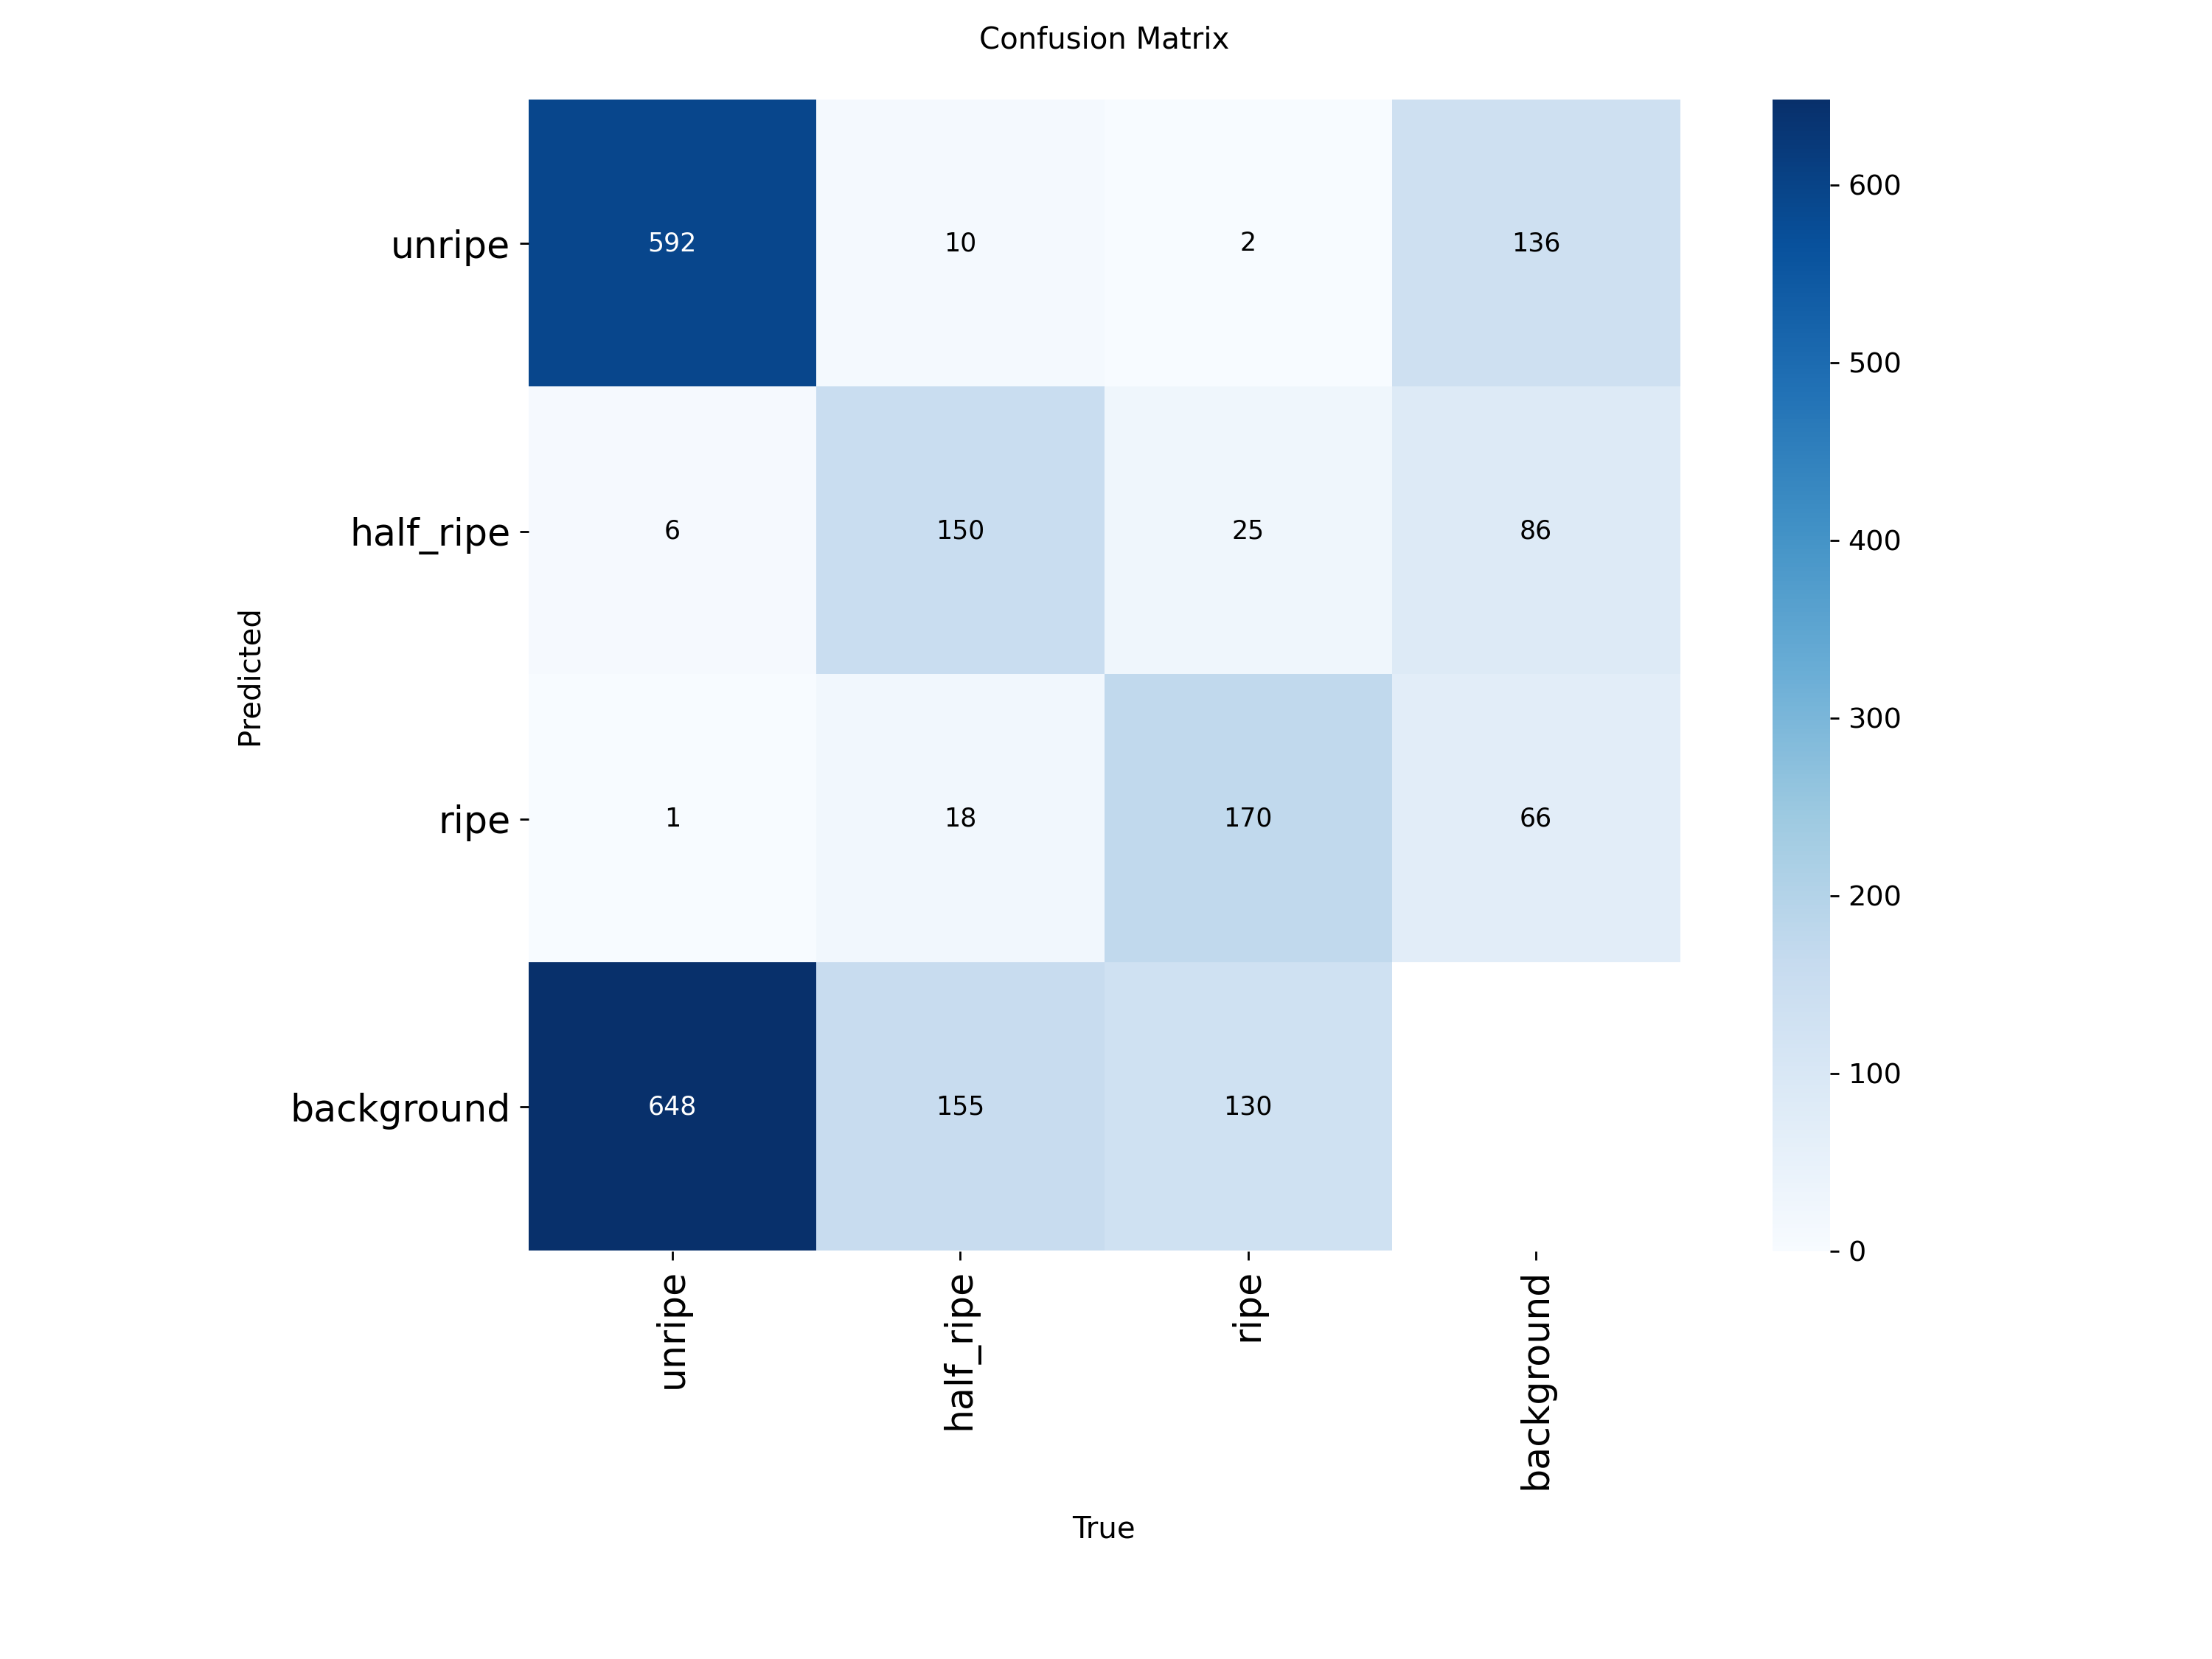

In [45]:
from PIL import Image
Image.open("/kaggle/working/runs/detect/tomato_maturity/yolov8n_run2/confusion_matrix.png")

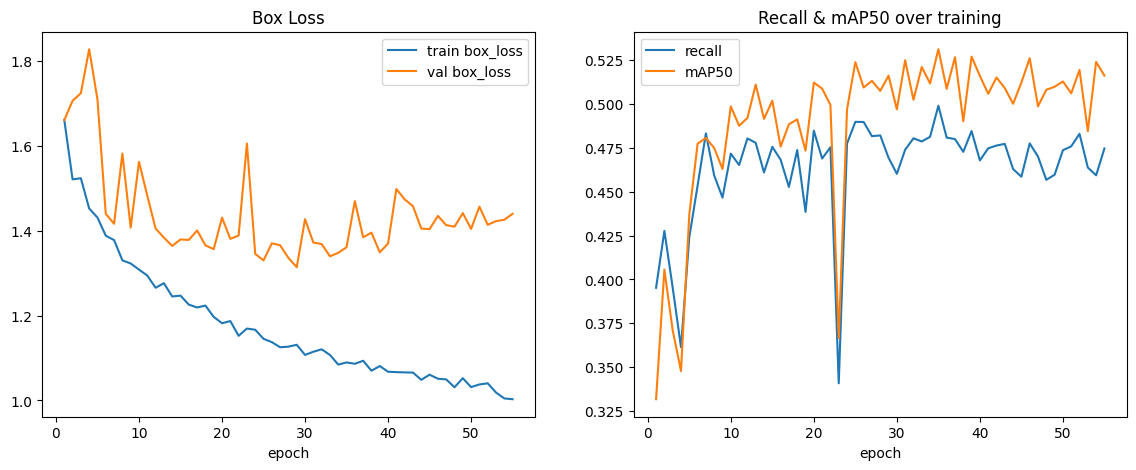

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

results_csv = "/kaggle/working/runs/detect/tomato_maturity/yolov8n_run2/results.csv"
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(df['epoch'], df['train/box_loss'], label='train box_loss')
axes[0].plot(df['epoch'], df['val/box_loss'], label='val box_loss')
axes[0].set_title('Box Loss'); axes[0].legend(); axes[0].set_xlabel('epoch')

axes[1].plot(df['epoch'], df['metrics/recall(B)'], label='recall')
axes[1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50')
axes[1].set_title('Recall & mAP50 over training'); axes[1].legend(); axes[1].set_xlabel('epoch')
plt.show()

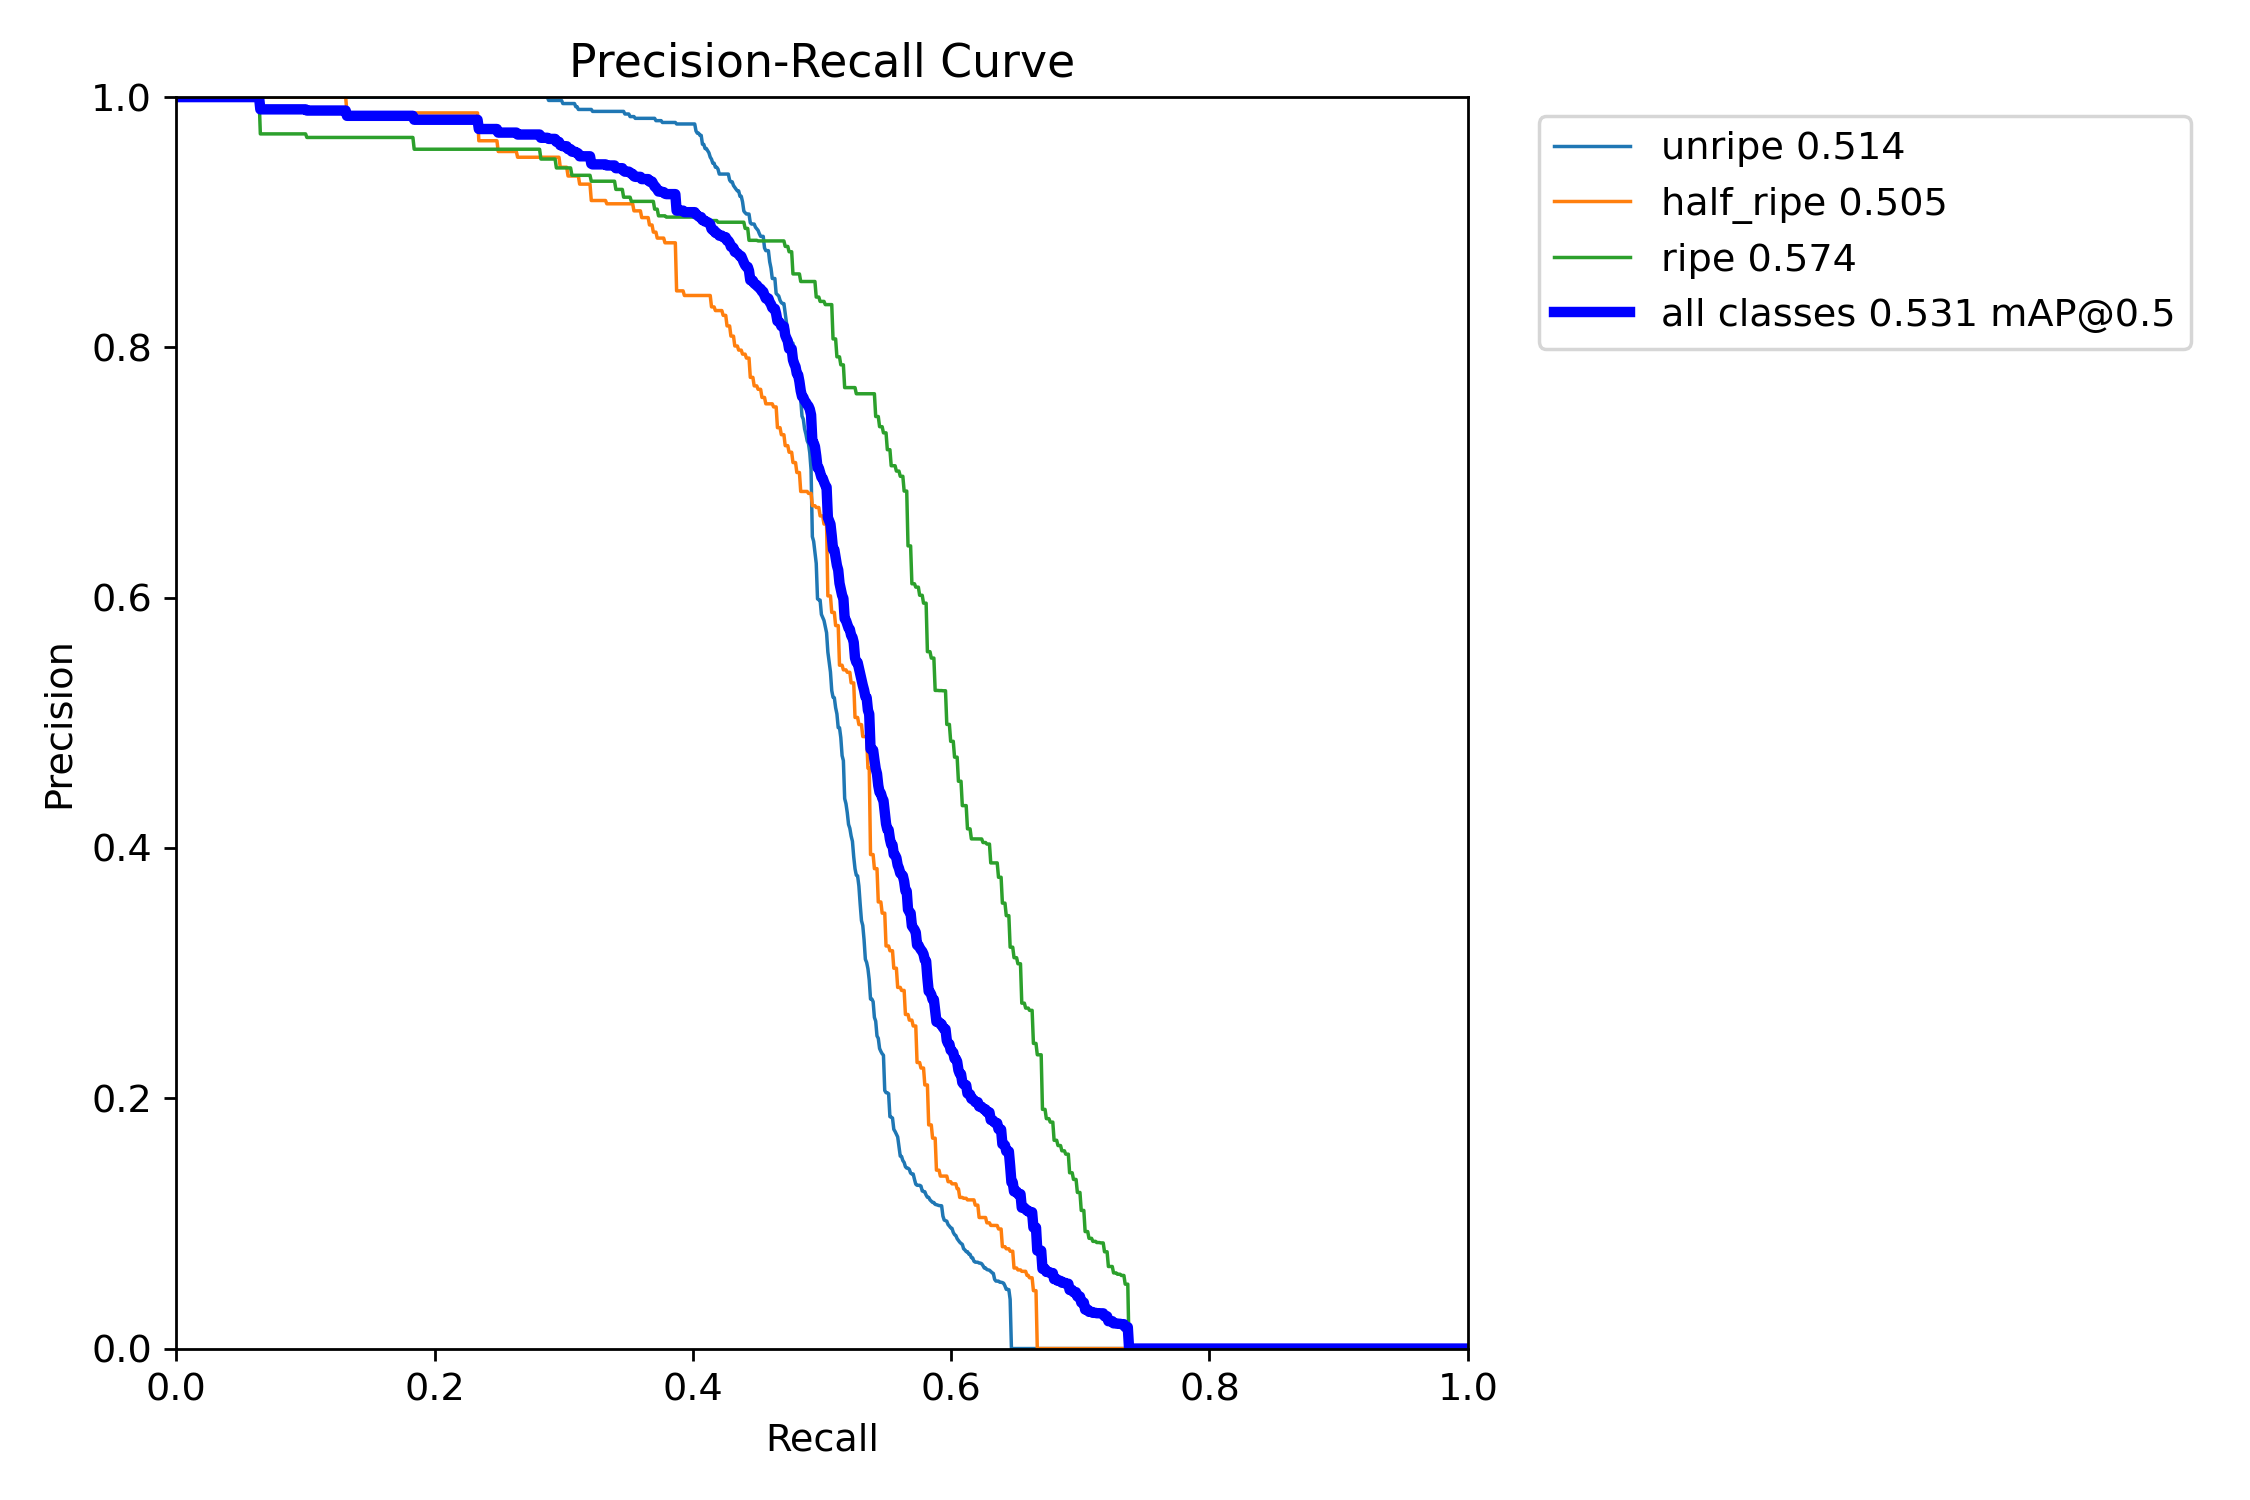

In [49]:
from PIL import Image
Image.open("/kaggle/working/runs/detect/tomato_maturity/yolov8n_run2/BoxPR_curve.png")

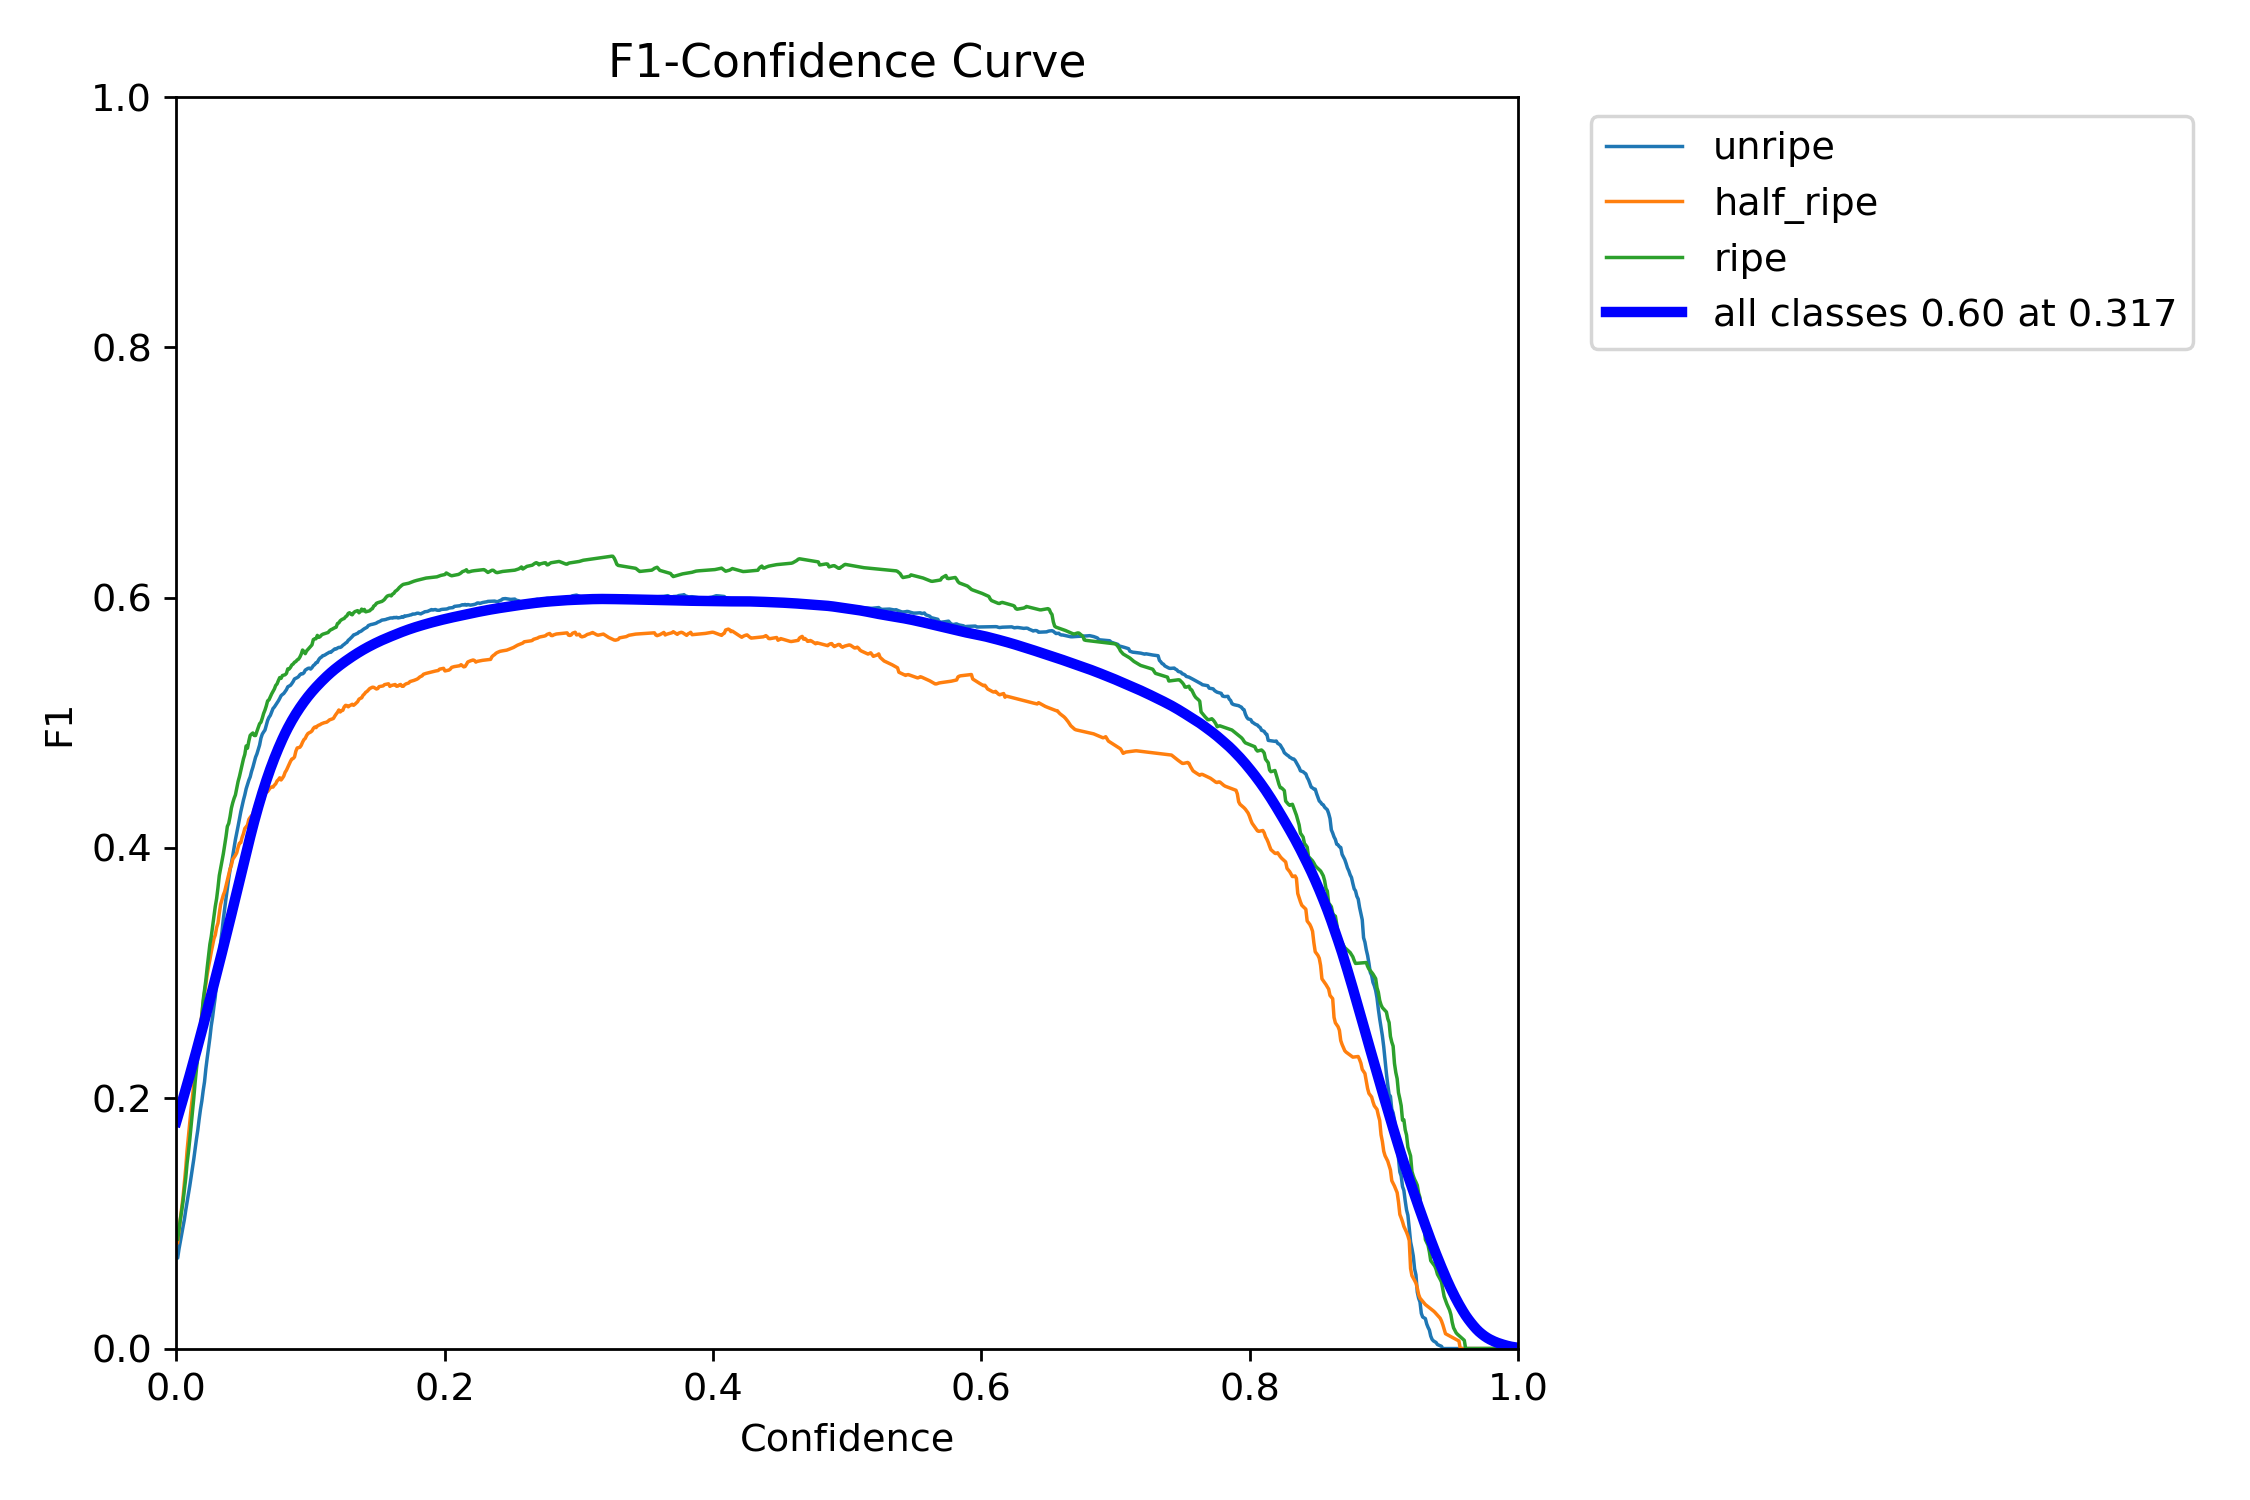

In [48]:
# for threshold tuning
Image.open("/kaggle/working/runs/detect/tomato_maturity/yolov8n_run2/BoxF1_curve.png")

# Testing the model

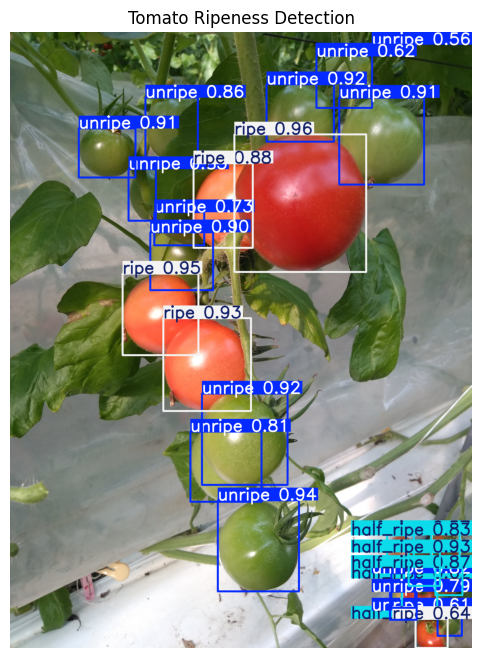

Found 28 tomatoes:
  1. ripe       | confidence: 0.96 | bbox: [1515.8, 691.5, 2405.4, 1620.6]
  2. ripe       | confidence: 0.95 | bbox: [760.0, 1631.9, 1272.3, 2182.2]
  3. unripe     | confidence: 0.94 | bbox: [1403.8, 3162.8, 1951.0, 3777.2]
  4. half_ripe  | confidence: 0.93 | bbox: [2692.7, 3513.4, 2903.3, 3740.1]
  5. ripe       | confidence: 0.93 | bbox: [1035.6, 1932.0, 1627.2, 2559.8]
  6. unripe     | confidence: 0.92 | bbox: [1732.0, 352.2, 2187.9, 740.3]
  7. unripe     | confidence: 0.92 | bbox: [1296.4, 2441.6, 1874.2, 3058.8]
  8. unripe     | confidence: 0.91 | bbox: [2223.2, 443.0, 2796.5, 1030.1]
  9. unripe     | confidence: 0.91 | bbox: [464.8, 650.9, 847.5, 982.1]
  10. unripe     | confidence: 0.90 | bbox: [947.4, 1352.6, 1371.4, 1743.1]
  11. ripe       | confidence: 0.88 | bbox: [1239.6, 886.5, 1639.2, 1457.9]
  12. half_ripe  | confidence: 0.87 | bbox: [2872.4, 3618.9, 3055.1, 3803.3]
  13. unripe     | confidence: 0.86 | bbox: [914.1, 442.9, 1268.8, 847.7]
  1

In [50]:
# inference cell
# running best.pt on a test image and drawing the boxes+labels (what the GUI will call)
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# Load the trained model (best checkpoint) — updated to the deploy package path
best_model_path = "/kaggle/working/tomato_maturity_deploy/tomato_maturity_best.pt"
inference_model = YOLO(best_model_path)

def predict_ripeness(image_path, conf_threshold=0.4, save_path=None):
    """
    Runs detection + ripeness classification on a single image.
    Returns the annotated image (numpy array, RGB) and a list of detections.
    """
    results = inference_model.predict(
        source=image_path,
        conf=conf_threshold,
        imgsz=960,   # matches training resolution
        verbose=False
    )
    result = results[0]  # single image -> single result

    # Ultralytics draws boxes + class labels + confidence automatically
    annotated_bgr = result.plot()  # returns numpy array in BGR (OpenCV format)
    annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

    # Extract structured detections (useful for GUI logic later,
    # e.g. counting how many are ripe vs unripe)
    detections = []
    class_names = inference_model.names
    for box in result.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        xyxy = box.xyxy[0].tolist()  # [x1, y1, x2, y2]
        detections.append({
            "class": class_names[cls_id],
            "confidence": round(conf, 3),
            "bbox": [round(v, 1) for v in xyxy]
        })

    if save_path:
        cv2.imwrite(save_path, annotated_bgr)

    return annotated_rgb, detections


# --- Run on a test image ---
test_image_path = "/kaggle/input/datasets/mariambahi/test-image/IMG_20191215_112412.jpg"

annotated_img, detections = predict_ripeness(
    test_image_path,
    conf_threshold=0.4,
    save_path="/kaggle/working/sample_prediction.jpg"
)

# --- Display ---
plt.figure(figsize=(10, 8))
plt.imshow(annotated_img)
plt.axis("off")
plt.title("Tomato Ripeness Detection")
plt.show()

# --- Print structured results ---
print(f"Found {len(detections)} tomatoes:")
for i, d in enumerate(detections, 1):
    print(f"  {i}. {d['class']:10s} | confidence: {d['confidence']:.2f} | bbox: {d['bbox']}")

# Optional: quick summary count per ripeness stage — this is the kind of
# aggregate your GUI would show, e.g. "8 ripe, 2 half_ripe, 1 unripe -> harvest recommended"
from collections import Counter
counts = Counter(d["class"] for d in detections)
print("\nSummary:", dict(counts))